<a href="https://www.kaggle.com/code/lalit7881/e-commerce-pok-mon-card-pricing-data-eda?scriptVersionId=317777292" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/e-commerce-pokmon-card-pricing-data/pokemon_cards_ultimate_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/e-commerce-pokmon-card-pricing-data/pokemon_cards_ultimate_2026.csv")

In [3]:
df.head()

,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
0,Ceruledge ex SAR 203/187 SV8a Terastal Fest ex...,Ceruledge,SV8A,203/187,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,20.99,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
1,Zacian V Holo SAR 225/172 S12a VSTAR Universe ...,Zacian,S12A,225/172,SAR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,15.17,Uncommon,United Kingdom,15,0,2,2.0,5.0,2026.0
2,Piplup AR 085/080 M2 Japanese Pokemon Card Jap...,Piplup,INFERNO X,085/080,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,3.96,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
3,POKEMON Card Kyurem EX 25/98 XY Ancient Origin...,Kyurem,XY,25/98,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,3.12,Common,United Kingdom,15,0,2,2.0,5.0,2026.0
4,Pokemon Card Vulpix AR 067/063 M1L Mega Brave ...,Vulpix,MEGA BRAVE,067/063,AR,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,2.71,Common,United Kingdom,15,0,2,2.0,5.0,2026.0


In [4]:
df.tail()

,title,pokemon_name,set_name,card_number,rarity_class,language,category,condition_std,is_graded,grading_company,...,currency,price_usd,price_tier_usd,seller_country,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
537,Charizard EX 151 Special Illustration Rare Car...,Charizard,Unknown,199/165,SIR,English,Single Cards,Near Mint,0,NaN,...,GBP,394.35,Ultra Rare,United Kingdom,4,0,13,5.0,5.0,2026.0
538,Mega Lucario ex MEP 033 Promo Full Art Holo As...,Lucario,Unknown,NaN,Unknown,English,Single Cards,Near Mint,0,NaN,...,GBP,36.16,Uncommon,United Kingdom,5,0,10,5.0,5.0,2026.0
539,Mega Blastoise EX XY Evolutions Holo Full Art ...,Blastoise,XY,NaN,Rare,English,Single Cards,Near Mint,0,NaN,...,EUR,11.73,Uncommon,Germany,1,1,6,5.0,5.0,2026.0
540,Mega Venusaur EX 177/132 Full Art Secret Pokem...,Venusaur,Unknown,177/132,Rare,English,Single Cards,Near Mint,0,NaN,...,GBP,152.12,Rare,United Kingdom,1,0,3,5.0,5.0,2026.0
541,Japanese Dragonite 042/078 XY6 Emerald Break N...,Dragonite,XY6,042/078,Unknown,Japanese,Single Cards,Near Mint,0,NaN,...,GBP,6.80,Common,United Kingdom,1,0,5,5.0,5.0,2026.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 542 non-null    object 
 1   pokemon_name          542 non-null    object 
 2   set_name              542 non-null    object 
 3   card_number           411 non-null    object 
 4   rarity_class          542 non-null    object 
 5   language              542 non-null    object 
 6   category              542 non-null    object 
 7   condition_std         542 non-null    object 
 8   is_graded             542 non-null    int64  
 9   grading_company       39 non-null     object 
 10  numeric_grade         30 non-null     float64
 11  is_holo               542 non-null    int64  
 12  is_full_art           542 non-null    int64  
 13  is_v_card             542 non-null    int64  
 14  is_ex_card            542 non-null    int64  
 15  is_gx_card            5

In [6]:
df.describe()

,is_graded,numeric_grade,is_holo,is_full_art,is_v_card,is_ex_card,is_gx_card,is_promo,is_shadowless,is_1st_edition,is_rainbow,is_gold,price,price_usd,seller_listing_count,ships_worldwide,image_count,days_since_sold,sale_month,sale_year
count,542.000000,30.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,542.000000,538.000000,538.0,538.0
mean,0.071956,9.600000,0.302583,0.049815,0.049815,0.166052,0.025830,0.086716,0.001845,0.049815,0.001845,0.005535,31.595166,39.830111,39.754613,0.236162,4.503690,3.730483,5.0,2026.0
std,0.258653,0.498273,0.459801,0.217765,0.217765,0.372471,0.158775,0.281678,0.042954,0.217765,0.042954,0.074260,124.768916,151.256000,42.454550,0.425115,3.864023,0.854302,0.0,0.0
min,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.360000,0.490000,1.000000,0.000000,2.000000,2.000000,5.0,2026.0
25%,0.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,2.032500,4.000000,0.000000,2.000000,3.000000,5.0,2026.0
50%,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.200000,5.340000,26.000000,0.000000,2.000000,4.000000,5.0,2026.0
75%,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.502500,15.160000,88.000000,0.000000,6.000000,4.000000,5.0,2026.0
max,1.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1475.000000,1591.410000,114.000000,1.000000,22.000000,5.000000,5.0,2026.0


In [7]:
df.isnull().sum()

title                     0
pokemon_name              0
set_name                  0
card_number             131
rarity_class              0
language                  0
category                  0
condition_std             0
is_graded                 0
grading_company         503
numeric_grade           512
is_holo                   0
is_full_art               0
is_v_card                 0
is_ex_card                0
is_gx_card                0
is_promo                  0
is_shadowless             0
is_1st_edition            0
is_rainbow                0
is_gold                   0
price                     0
currency                  0
price_usd                 0
price_tier_usd            0
seller_country            0
seller_listing_count      0
ships_worldwide           0
image_count               0
days_since_sold           4
sale_month                4
sale_year                 4
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.dtypes

title                    object
pokemon_name             object
set_name                 object
card_number              object
rarity_class             object
language                 object
category                 object
condition_std            object
is_graded                 int64
grading_company          object
numeric_grade           float64
is_holo                   int64
is_full_art               int64
is_v_card                 int64
is_ex_card                int64
is_gx_card                int64
is_promo                  int64
is_shadowless             int64
is_1st_edition            int64
is_rainbow                int64
is_gold                   int64
price                   float64
currency                 object
price_usd               float64
price_tier_usd           object
seller_country           object
seller_listing_count      int64
ships_worldwide           int64
image_count               int64
days_since_sold         float64
sale_month              float64
sale_yea

In [10]:
df.shape

(542, 32)

In [11]:
df.columns

Index(['title', 'pokemon_name', 'set_name', 'card_number', 'rarity_class',
       'language', 'category', 'condition_std', 'is_graded', 'grading_company',
       'numeric_grade', 'is_holo', 'is_full_art', 'is_v_card', 'is_ex_card',
       'is_gx_card', 'is_promo', 'is_shadowless', 'is_1st_edition',
       'is_rainbow', 'is_gold', 'price', 'currency', 'price_usd',
       'price_tier_usd', 'seller_country', 'seller_listing_count',
       'ships_worldwide', 'image_count', 'days_since_sold', 'sale_month',
       'sale_year'],
      dtype='object')

In [12]:
df.nunique()

title                   536
pokemon_name             76
set_name                 80
card_number             387
rarity_class             13
language                  6
category                  2
condition_std            10
is_graded                 2
grading_company           4
numeric_grade             2
is_holo                   2
is_full_art               2
is_v_card                 2
is_ex_card                2
is_gx_card                2
is_promo                  2
is_shadowless             2
is_1st_edition            2
is_rainbow                2
is_gold                   2
price                   234
currency                  3
price_usd               246
price_tier_usd            5
seller_country            5
seller_listing_count     18
ships_worldwide           2
image_count              18
days_since_sold           4
sale_month                1
sale_year                 1
dtype: int64

## EDA

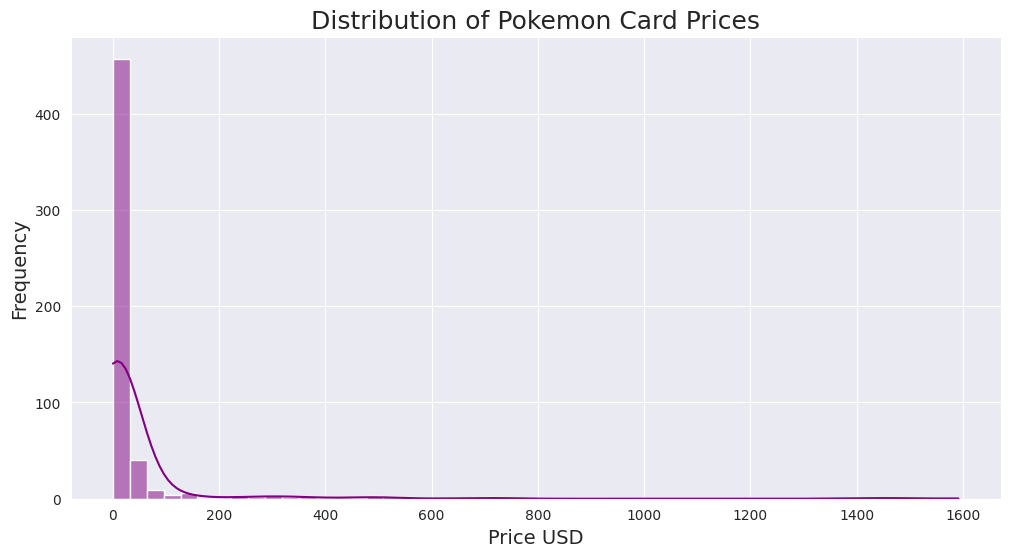

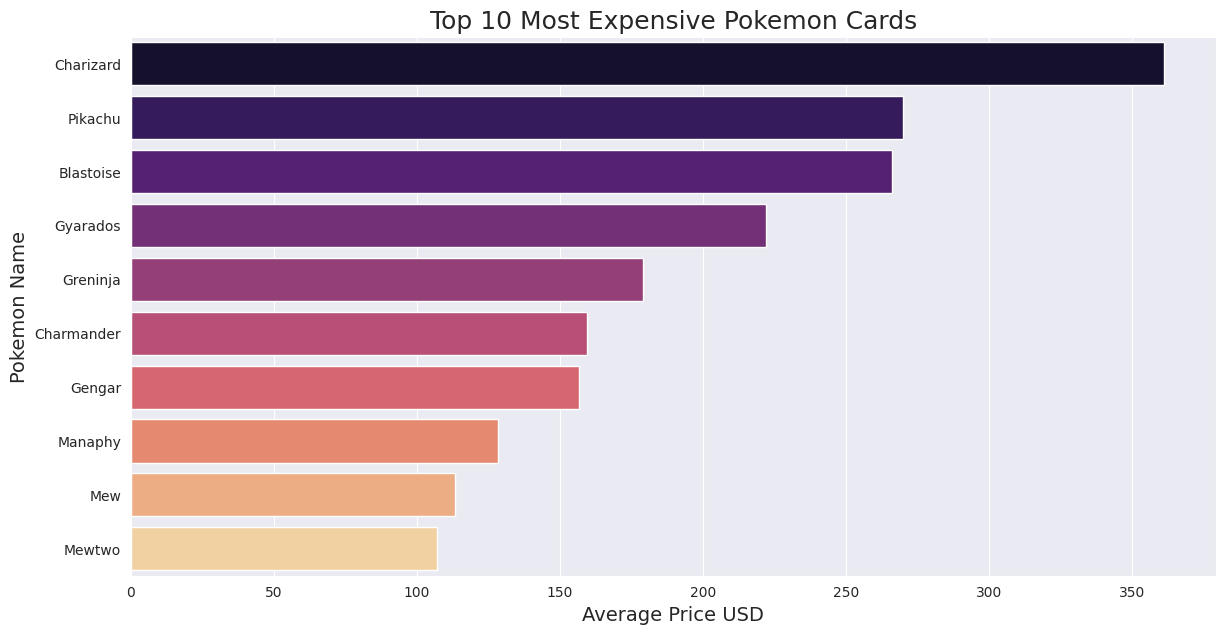

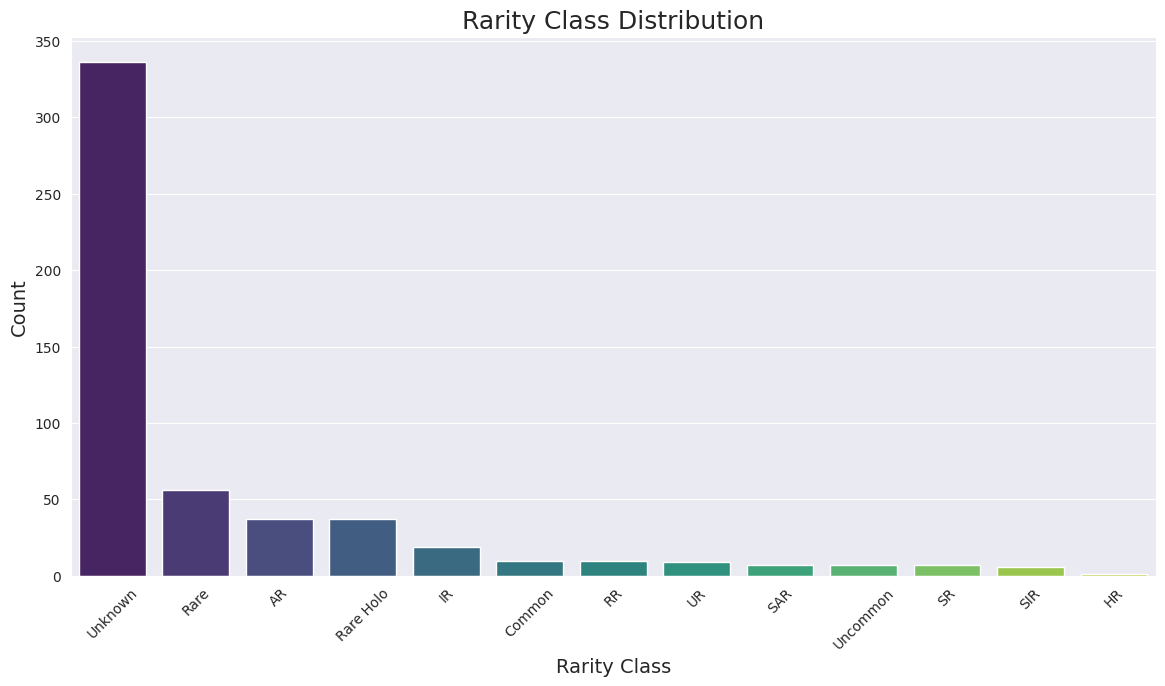

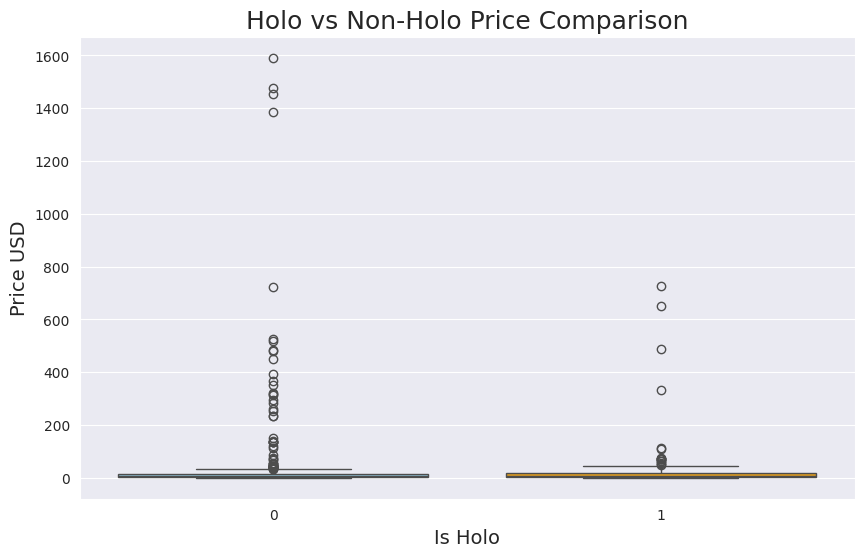

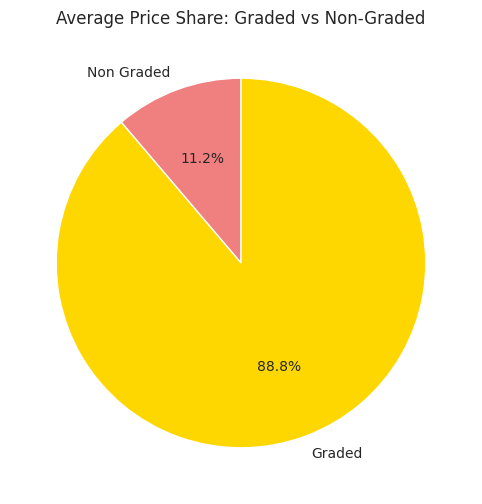

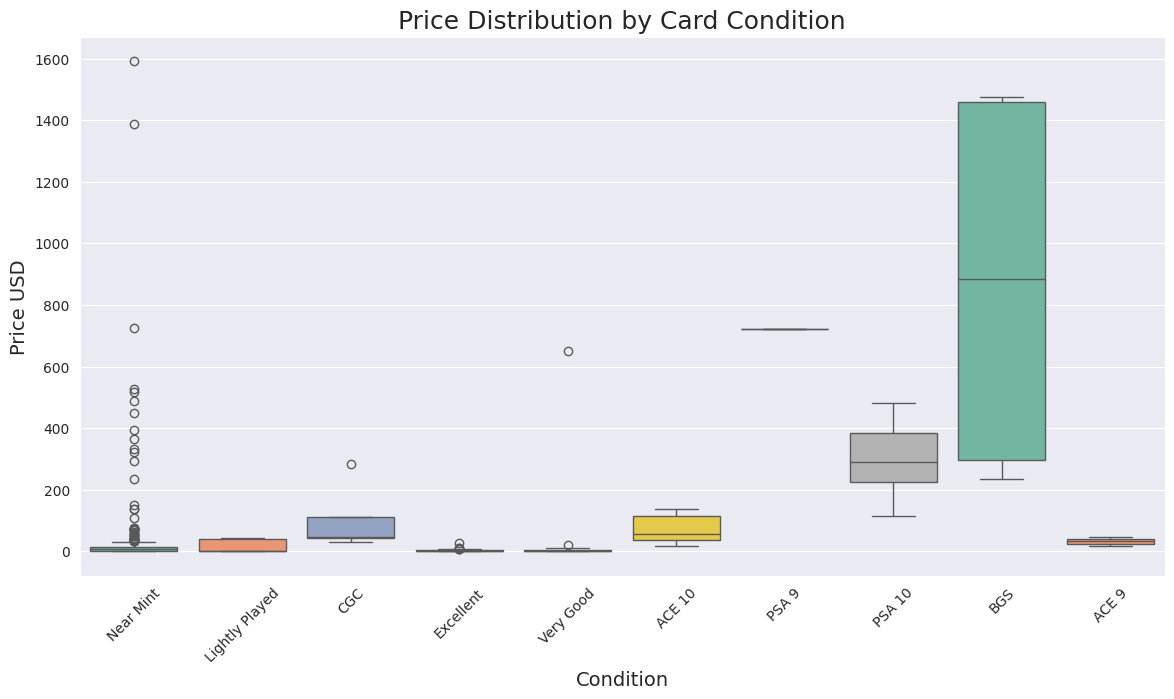

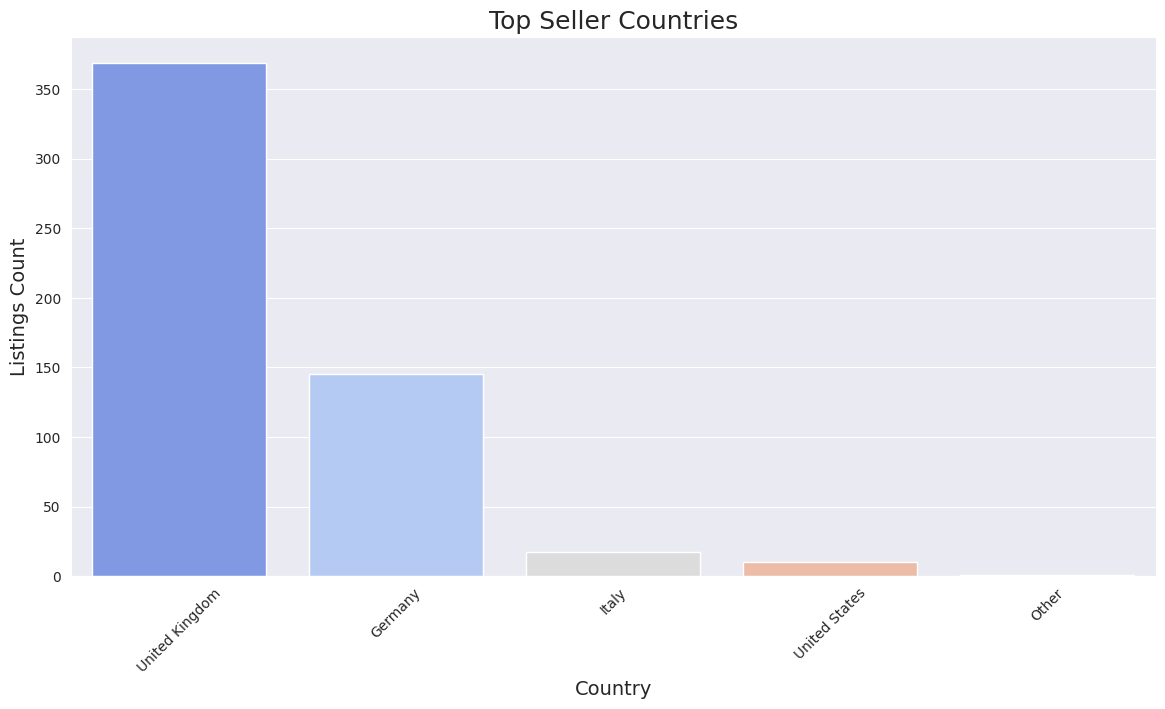

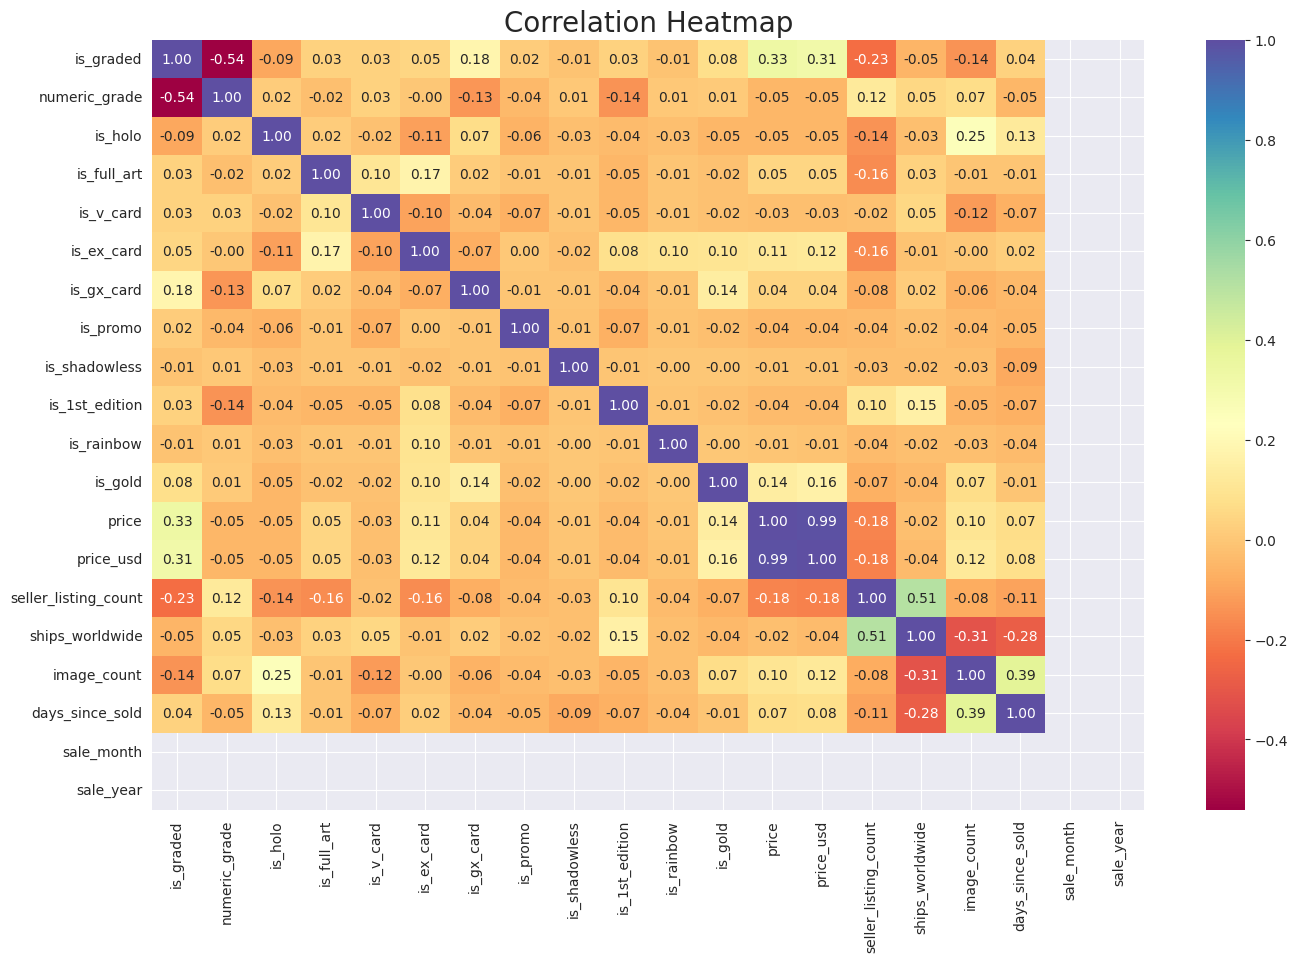

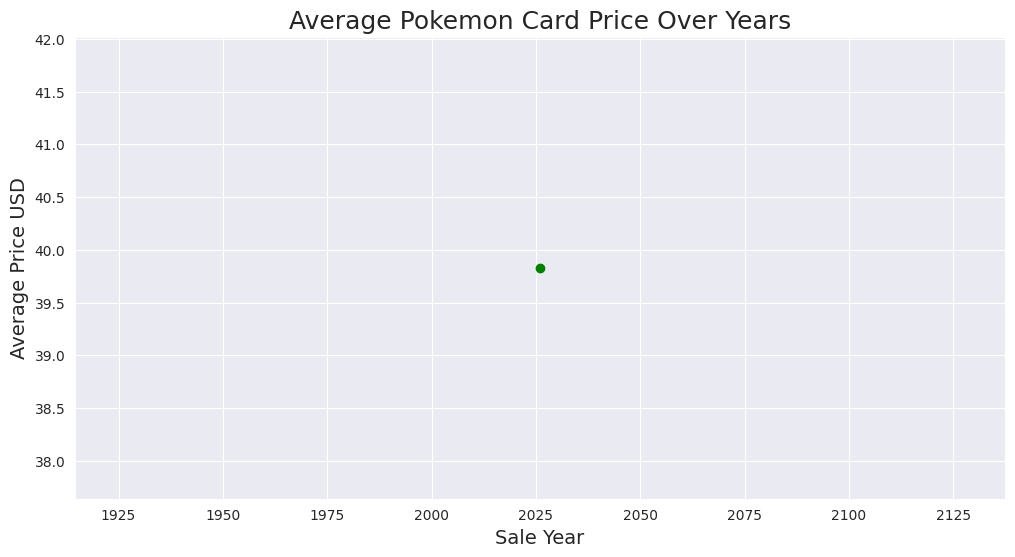

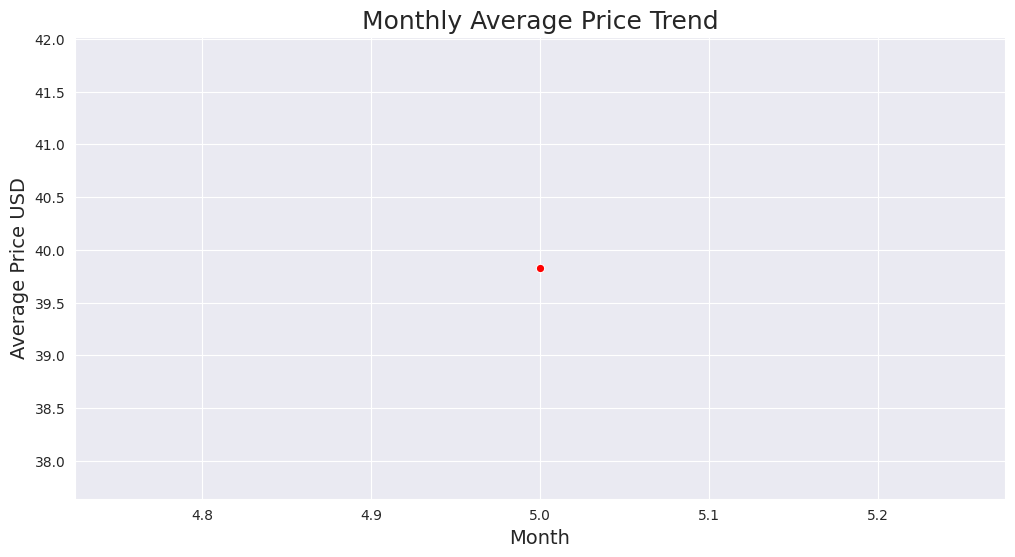

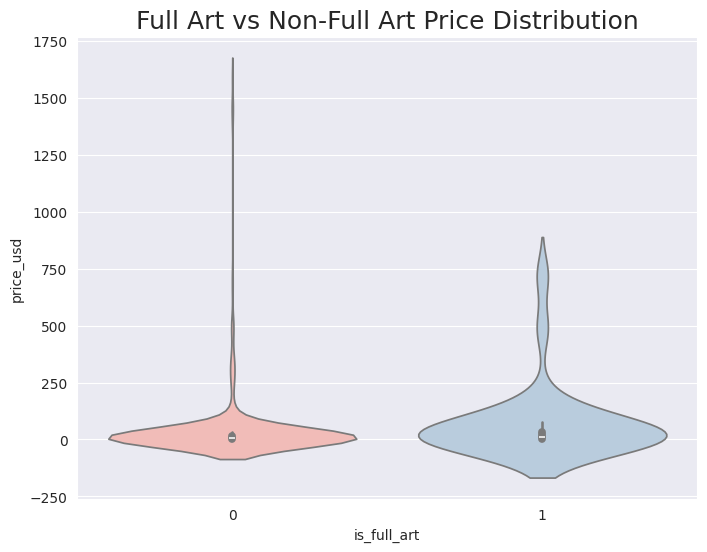

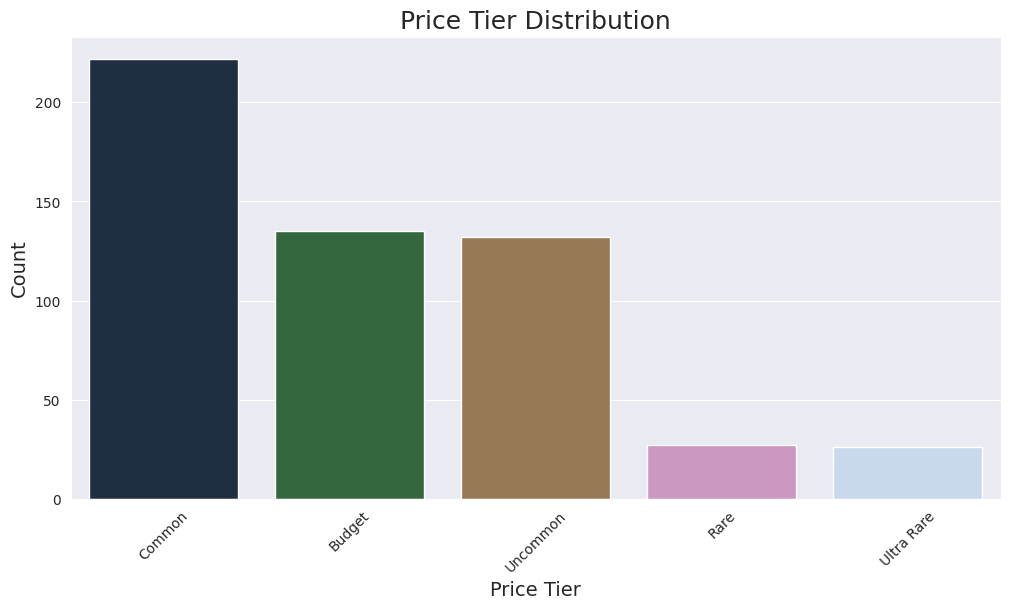

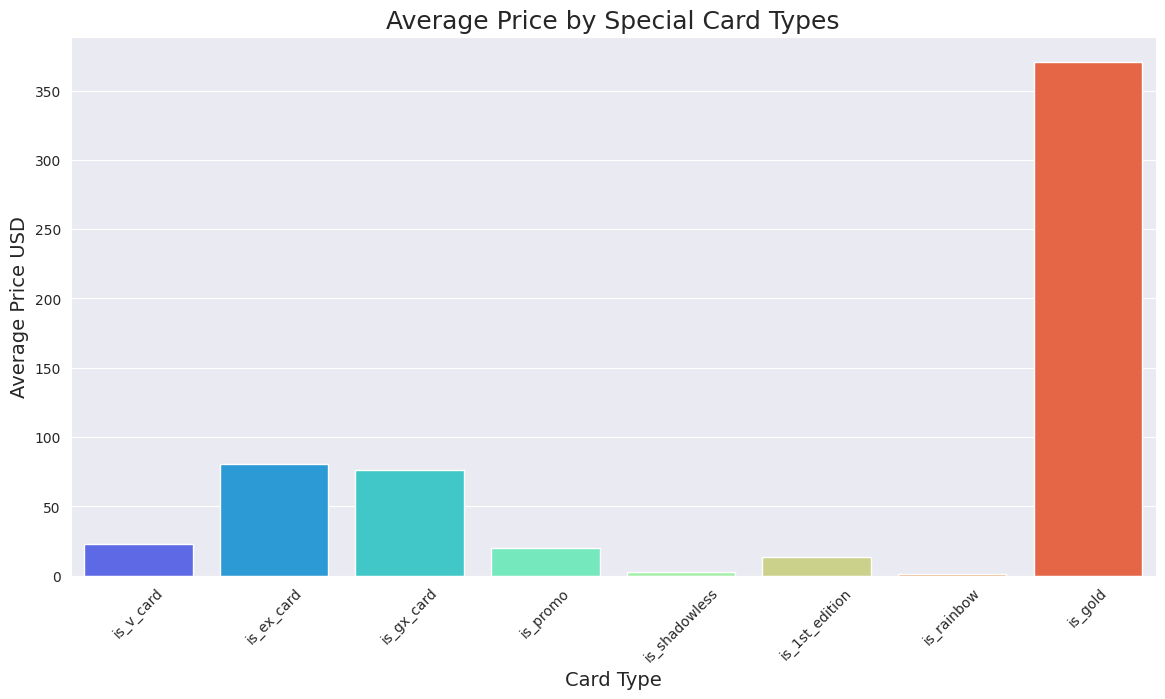

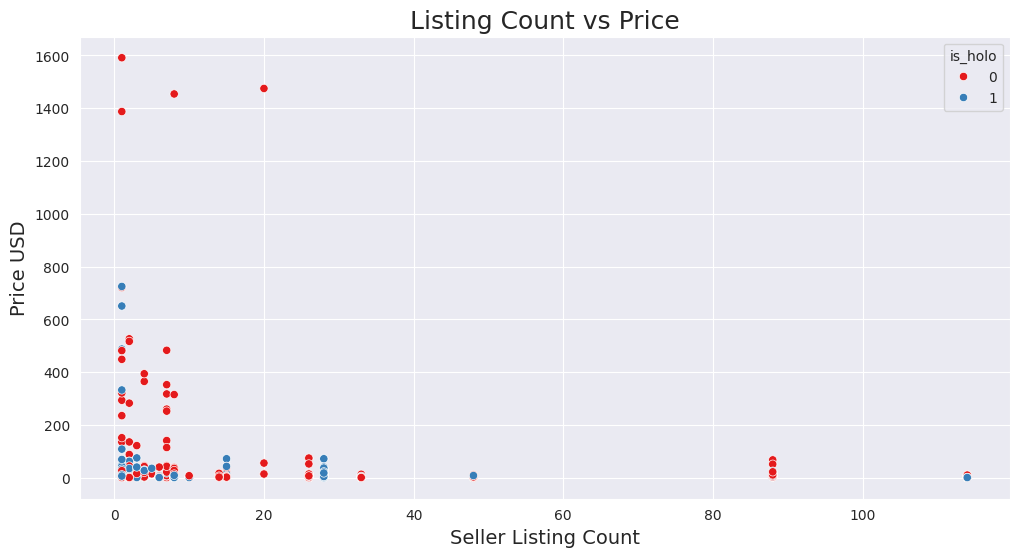

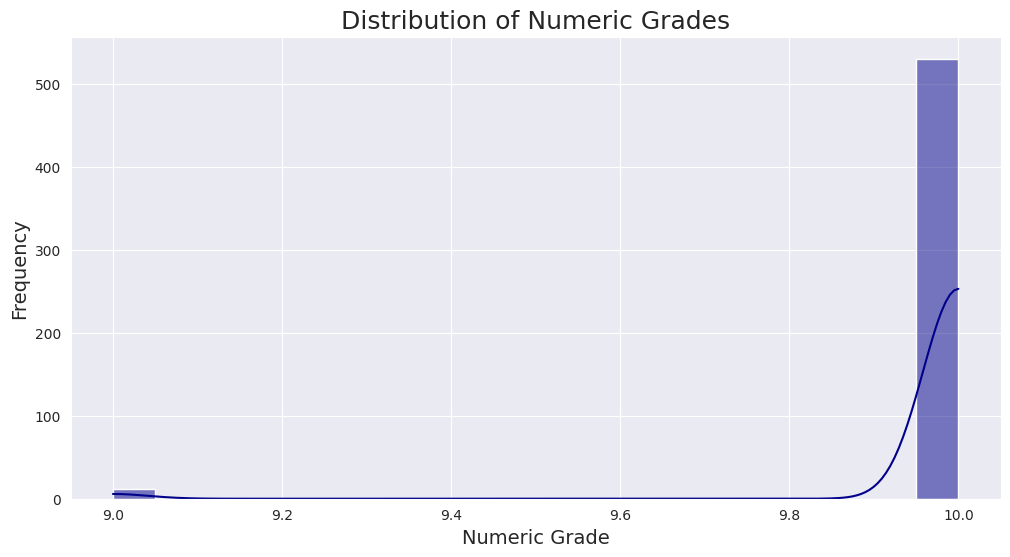

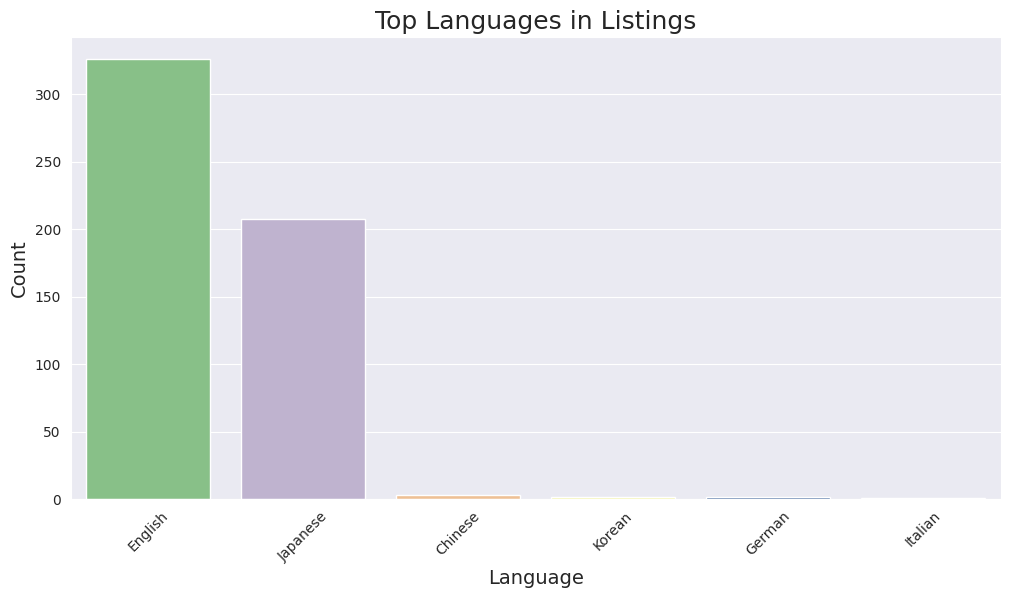

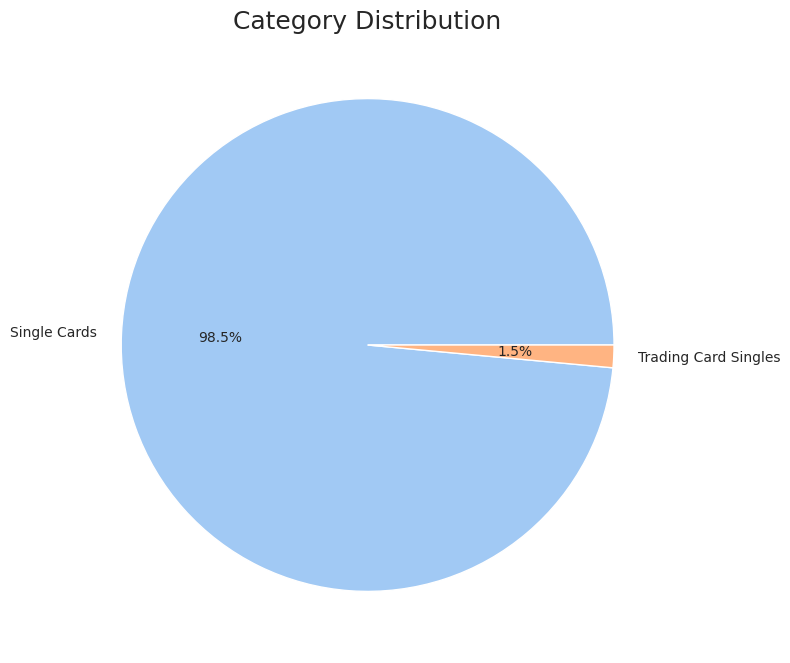

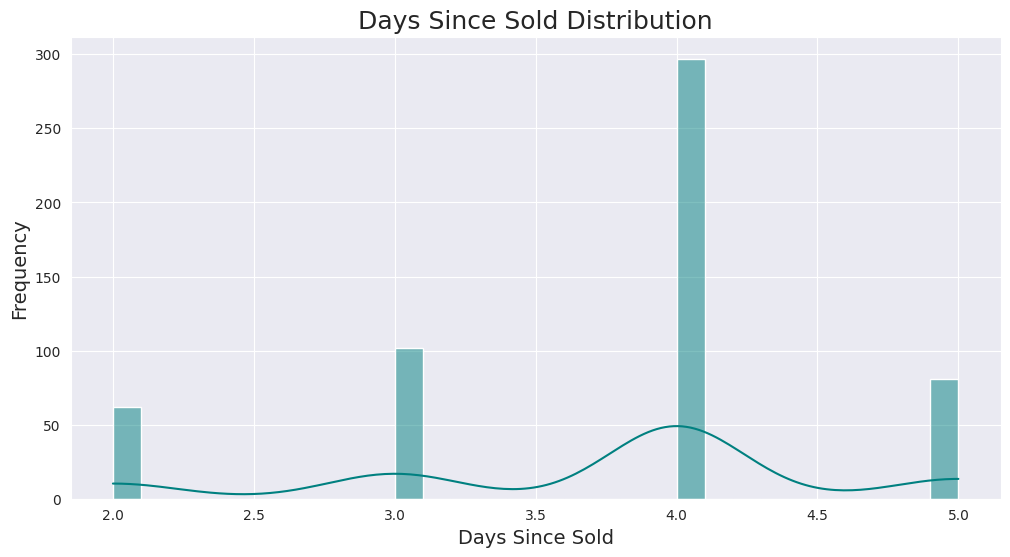

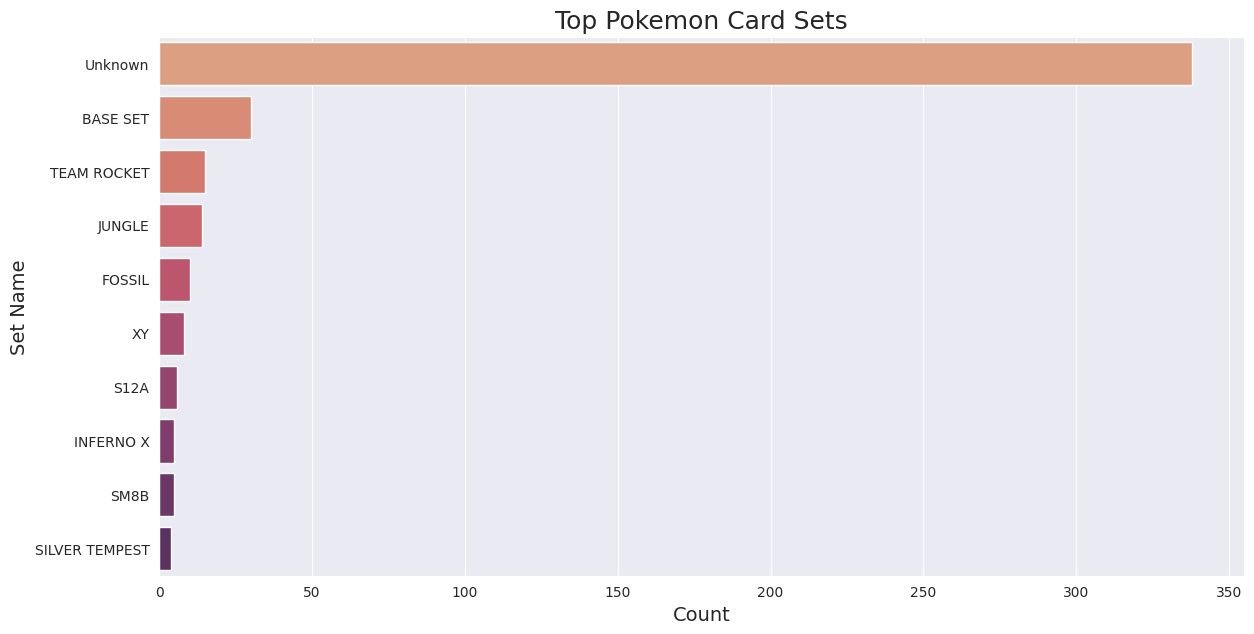

In [13]:
# Fill missing categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# Fill missing numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# ============================================================
# STYLE SETTINGS
# ============================================================

sns.set_style("darkgrid")

# ============================================================
# 1. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['price_usd'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title("Distribution of Pokemon Card Prices", fontsize=18)
plt.xlabel("Price USD", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 2. TOP 10 MOST EXPENSIVE POKEMON CARDS
# ============================================================

top_cards = (
    df.groupby('pokemon_name')['price_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_cards.values,
    y=top_cards.index,
    palette='magma'
)

plt.title("Top 10 Most Expensive Pokemon Cards", fontsize=18)
plt.xlabel("Average Price USD", fontsize=14)
plt.ylabel("Pokemon Name", fontsize=14)

plt.show()

# ============================================================
# 3. RARITY CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(14,7))

rarity_counts = df['rarity_class'].value_counts()

sns.barplot(
    x=rarity_counts.index,
    y=rarity_counts.values,
    palette='viridis'
)

plt.title("Rarity Class Distribution", fontsize=18)
plt.xlabel("Rarity Class", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 4. HOLO VS NON-HOLO PRICE COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='is_holo',
    y='price_usd',
    data=df,
    palette=['skyblue', 'orange']
)

plt.title("Holo vs Non-Holo Price Comparison", fontsize=18)
plt.xlabel("Is Holo", fontsize=14)
plt.ylabel("Price USD", fontsize=14)

plt.show()

# ============================================================
# 5. GRADED VS NON-GRADED CARDS
# ============================================================

graded_price = (
    df.groupby('is_graded')['price_usd']
    .mean()
)

plt.figure(figsize=(8,6))

plt.pie(
    graded_price,
    labels=['Non Graded', 'Graded'],
    autopct='%1.1f%%',
    colors=['lightcoral', 'gold'],
    startangle=90
)

plt.title("Average Price Share: Graded vs Non-Graded")

plt.show()

# ============================================================
# 6. PRICE BY CONDITION
# ============================================================

plt.figure(figsize=(14,7))

sns.boxplot(
    x='condition_std',
    y='price_usd',
    data=df,
    palette='Set2'
)

plt.title("Price Distribution by Card Condition", fontsize=18)
plt.xlabel("Condition", fontsize=14)
plt.ylabel("Price USD", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 7. SALES BY COUNTRY
# ============================================================

top_countries = df['seller_country'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values,
    palette='coolwarm'
)

plt.title("Top Seller Countries", fontsize=18)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Listings Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 8. CORRELATION HEATMAP
# ============================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# ============================================================
# 9. PRICE TREND OVER YEARS
# ============================================================

yearly_price = (
    df.groupby('sale_year')['price_usd']
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly_price.index,
    yearly_price.values,
    marker='o',
    linewidth=3,
    color='green'
)

plt.title("Average Pokemon Card Price Over Years", fontsize=18)
plt.xlabel("Sale Year", fontsize=14)
plt.ylabel("Average Price USD", fontsize=14)

plt.grid(True)

plt.show()

# ============================================================
# 10. MONTHLY SALES TREND
# ============================================================

monthly_sales = (
    df.groupby('sale_month')['price_usd']
    .mean()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o',
    color='red',
    linewidth=3
)

plt.title("Monthly Average Price Trend", fontsize=18)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Average Price USD", fontsize=14)

plt.show()

# ============================================================
# 11. FULL ART CARD ANALYSIS
# ============================================================

plt.figure(figsize=(8,6))

sns.violinplot(
    x='is_full_art',
    y='price_usd',
    data=df,
    palette='Pastel1'
)

plt.title("Full Art vs Non-Full Art Price Distribution", fontsize=18)

plt.show()

# ============================================================
# 12. PRICE TIER DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

tier_counts = df['price_tier_usd'].value_counts()

sns.barplot(
    x=tier_counts.index,
    y=tier_counts.values,
    palette='cubehelix'
)

plt.title("Price Tier Distribution", fontsize=18)
plt.xlabel("Price Tier", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 13. CARD TYPE ANALYSIS
# ============================================================

card_types = [
    'is_v_card',
    'is_ex_card',
    'is_gx_card',
    'is_promo',
    'is_shadowless',
    'is_1st_edition',
    'is_rainbow',
    'is_gold'
]

avg_prices = []

for card in card_types:
    avg_prices.append(df.groupby(card)['price_usd'].mean()[1])

plt.figure(figsize=(14,7))

sns.barplot(
    x=card_types,
    y=avg_prices,
    palette='rainbow'
)

plt.title("Average Price by Special Card Types", fontsize=18)
plt.xlabel("Card Type", fontsize=14)
plt.ylabel("Average Price USD", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 14. SCATTER PLOT: LISTING COUNT VS PRICE
# ============================================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='seller_listing_count',
    y='price_usd',
    hue='is_holo',
    palette='Set1',
    data=df
)

plt.title("Listing Count vs Price", fontsize=18)
plt.xlabel("Seller Listing Count", fontsize=14)
plt.ylabel("Price USD", fontsize=14)

plt.show()

# ============================================================
# 15. DISTRIBUTION OF NUMERIC GRADES
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['numeric_grade'],
    bins=20,
    kde=True,
    color='darkblue'
)

plt.title("Distribution of Numeric Grades", fontsize=18)
plt.xlabel("Numeric Grade", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 16. LANGUAGE DISTRIBUTION
# ============================================================

language_counts = df['language'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=language_counts.index,
    y=language_counts.values,
    palette='Accent'
)

plt.title("Top Languages in Listings", fontsize=18)
plt.xlabel("Language", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# 17. CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,8))

category_counts = df['category'].value_counts()

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)

plt.title("Category Distribution", fontsize=18)

plt.show()

# ============================================================
# 18. DAYS SINCE SOLD ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['days_since_sold'],
    bins=30,
    color='teal',
    kde=True
)

plt.title("Days Since Sold Distribution", fontsize=18)
plt.xlabel("Days Since Sold", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

# ============================================================
# 19. TOP SET NAMES
# ============================================================

top_sets = df['set_name'].value_counts().head(10)

plt.figure(figsize=(14,7))

sns.barplot(
    x=top_sets.values,
    y=top_sets.index,
    palette='flare'
)

plt.title("Top Pokemon Card Sets", fontsize=18)
plt.xlabel("Count", fontsize=14)
plt.ylabel("Set Name", fontsize=14)

plt.show()

## Feature engineering



TARGET COLUMN
price_tier_usd

Target Value Counts
price_tier_usd
Common        222
Budget        135
Uncommon      132
Rare           27
Ultra Rare     26
Name: count, dtype: int64


TARGET LABEL ENCODING
Budget --> 0
Common --> 1
Rare --> 2
Ultra Rare --> 3
Uncommon --> 4


CATEGORICAL COLUMNS
['title', 'pokemon_name', 'set_name', 'card_number', 'rarity_class', 'language', 'category', 'condition_std', 'grading_company', 'currency', 'seller_country']


NUMERICAL COLUMNS
['is_graded', 'numeric_grade', 'is_holo', 'is_full_art', 'is_v_card', 'is_ex_card', 'is_gx_card', 'is_promo', 'is_shadowless', 'is_1st_edition', 'is_rainbow', 'is_gold', 'seller_listing_count', 'ships_worldwide', 'image_count', 'days_since_sold', 'sale_month', 'sale_year']


TRAIN TEST SPLIT
X_train Shape : (433, 29)
X_test Shape  : (109, 29)
y_train Shape : (433,)
y_test Shape  : (109,)


LOGISTIC REGRESSION

Accuracy Score : 0.4128


CLASSIFICATION REPORT
------------------------------------------------------------


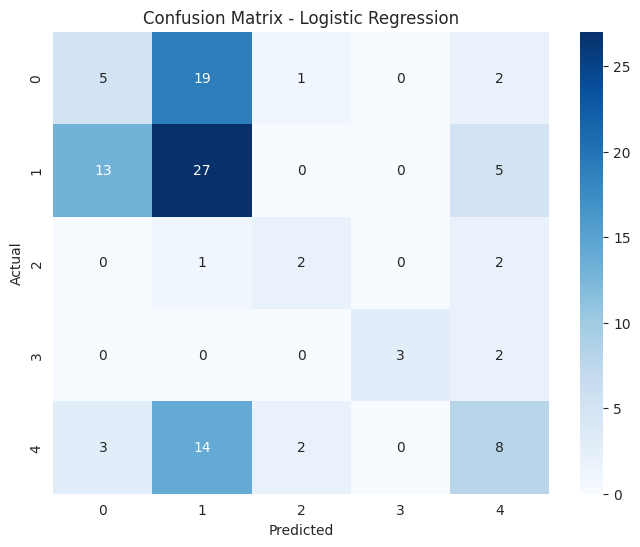


Multi-Class ROC AUC Score : 0.7787


NAIVE BAYES

Accuracy Score : 0.2385


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.36      0.33      0.35        27
           1       0.36      0.09      0.14        45
           2       0.09      0.40      0.15         5
           3       0.14      1.00      0.25         5
           4       0.38      0.22      0.28        27

    accuracy                           0.24       109
   macro avg       0.27      0.41      0.23       109
weighted avg       0.34      0.24      0.23       109



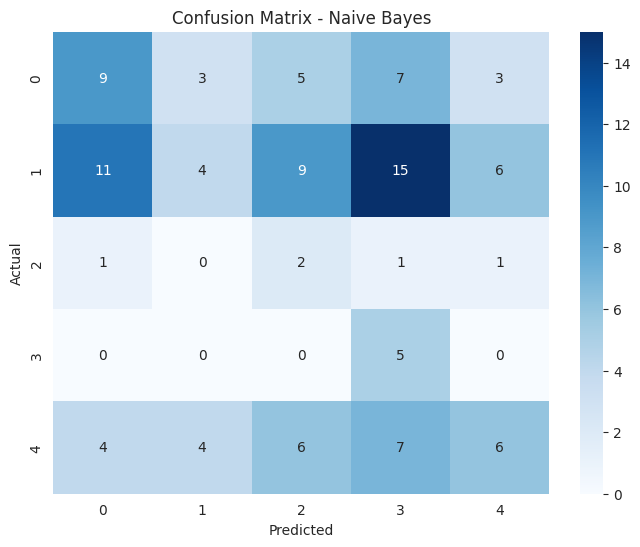


Multi-Class ROC AUC Score : 0.6367


DECISION TREE

Accuracy Score : 0.5780


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.57      0.59      0.58        27
           1       0.57      0.73      0.64        45
           2       0.50      0.40      0.44         5
           3       1.00      0.60      0.75         5
           4       0.56      0.33      0.42        27

    accuracy                           0.58       109
   macro avg       0.64      0.53      0.57       109
weighted avg       0.58      0.58      0.57       109



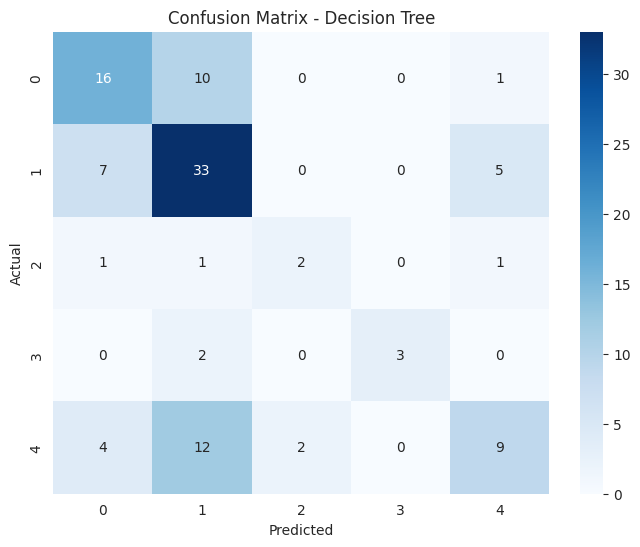


Multi-Class ROC AUC Score : 0.7018


RANDOM FOREST

Accuracy Score : 0.5780


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.44      0.53        27
           1       0.52      0.84      0.64        45
           2       1.00      0.20      0.33         5
           3       1.00      0.80      0.89         5
           4       0.62      0.30      0.40        27

    accuracy                           0.58       109
   macro avg       0.76      0.52      0.56       109
weighted avg       0.62      0.58      0.55       109



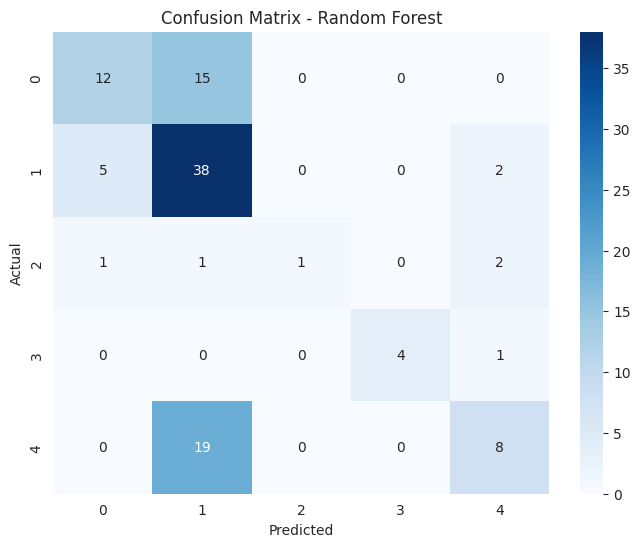


Multi-Class ROC AUC Score : 0.8161


GRADIENT BOOSTING

Accuracy Score : 0.5138


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.50      0.41      0.45        27
           1       0.49      0.69      0.57        45
           2       0.67      0.40      0.50         5
           3       0.57      0.80      0.67         5
           4       0.57      0.30      0.39        27

    accuracy                           0.51       109
   macro avg       0.56      0.52      0.52       109
weighted avg       0.53      0.51      0.50       109



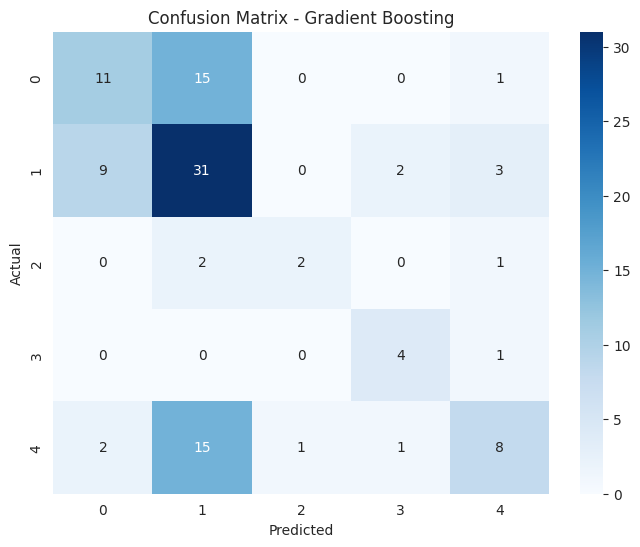


Multi-Class ROC AUC Score : 0.7950


KNN

Accuracy Score : 0.5046


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.50      0.67      0.57        27
           1       0.51      0.60      0.55        45
           2       0.50      0.40      0.44         5
           3       1.00      0.40      0.57         5
           4       0.43      0.22      0.29        27

    accuracy                           0.50       109
   macro avg       0.59      0.46      0.49       109
weighted avg       0.51      0.50      0.49       109



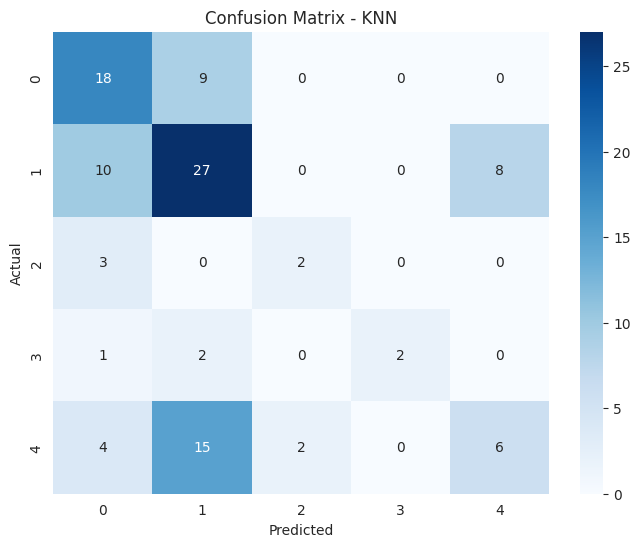


Multi-Class ROC AUC Score : 0.7518


SVM

Accuracy Score : 0.4771


CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.44      0.15      0.22        27
           1       0.45      0.87      0.59        45
           2       0.00      0.00      0.00         5
           3       1.00      0.40      0.57         5
           4       0.64      0.26      0.37        27

    accuracy                           0.48       109
   macro avg       0.51      0.33      0.35       109
weighted avg       0.50      0.48      0.42       109



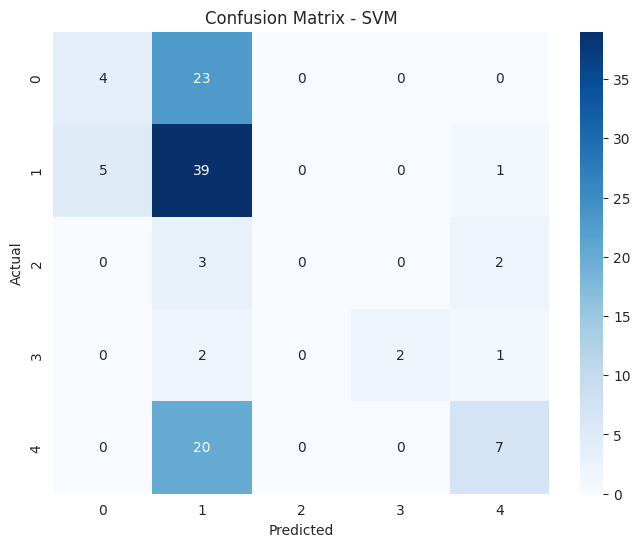


Multi-Class ROC AUC Score : 0.7851


FINAL MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
2        Decision Tree  0.577982  0.701770
3        Random Forest  0.577982  0.816147
4    Gradient Boosting  0.513761  0.794957
5                  KNN  0.504587  0.751843
6                  SVM  0.477064  0.785144
0  Logistic Regression  0.412844  0.778662
1          Naive Bayes  0.238532  0.636695


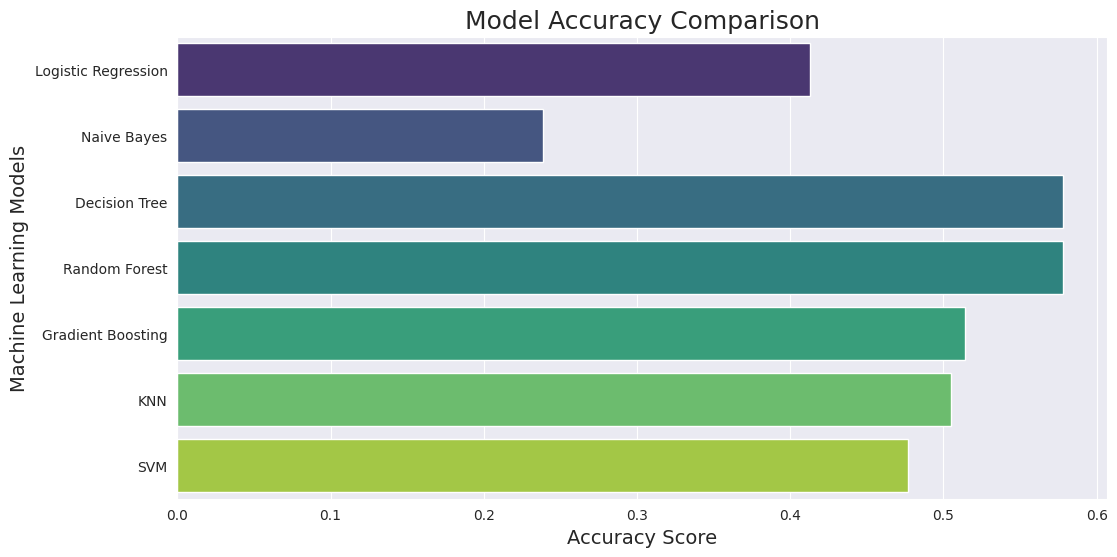

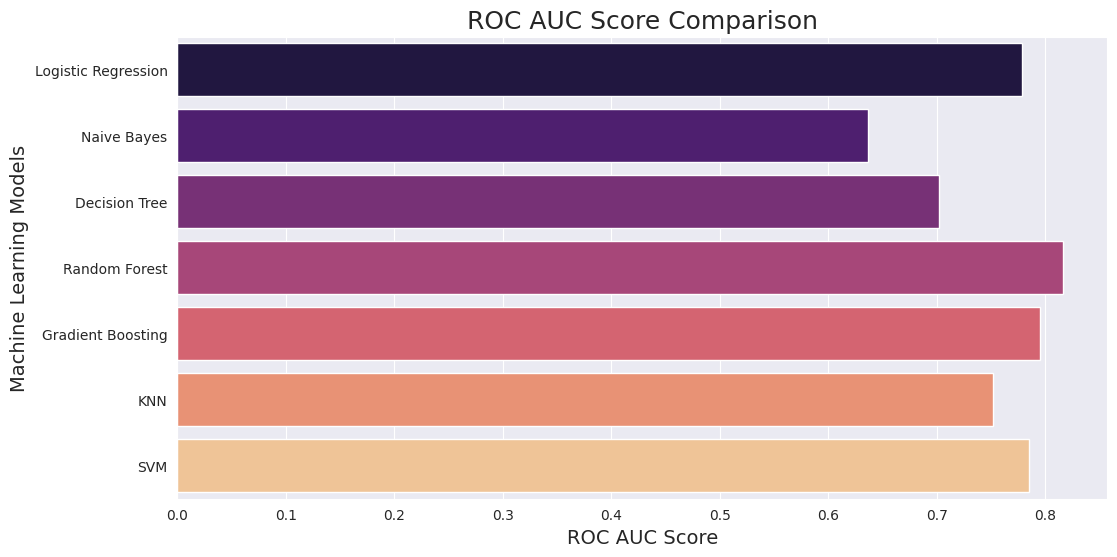



BEST MODEL
Best Model      : Decision Tree
Best Accuracy   : 0.5780
Best ROC AUC    : 0.7018


RANDOM FOREST FEATURE IMPORTANCE
                     Feature  Importance
12      seller_listing_count    0.044623
14               image_count    0.037091
15           days_since_sold    0.030756
504     pokemon_name_Unknown    0.020660
892      card_number_Unknown    0.015015
576         set_name_Unknown    0.013536
909        language_Japanese    0.013041
2                    is_holo    0.013038
5                 is_ex_card    0.012789
0                  is_graded    0.012167
905     rarity_class_Unknown    0.011620
13           ships_worldwide    0.011096
919  condition_std_Near Mint    0.010818
927  grading_company_Unknown    0.010653
907         language_English    0.010555
7                   is_promo    0.009119
931   seller_country_Germany    0.008969
929             currency_GBP    0.008742
928             currency_EUR    0.008570
898        rarity_class_Rare    0.008249


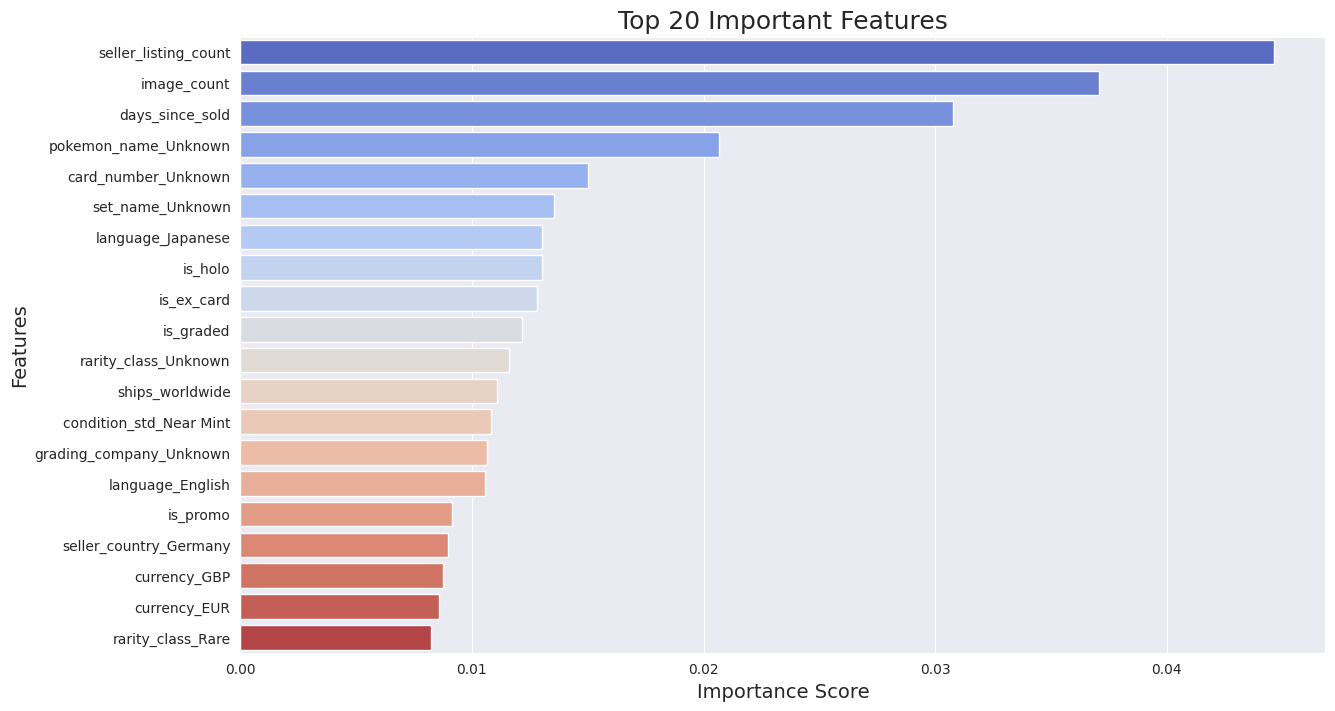



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [14]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay


# We will predict:
# price_tier_usd

target_column = "price_tier_usd"

print("\n")
print("="*70)
print("TARGET COLUMN")
print("="*70)

print(target_column)

print("\nTarget Value Counts")
print(df[target_column].value_counts())

# ============================================================
# DROP LEAKAGE COLUMNS
# ============================================================

# IMPORTANT:
# price and price_usd directly reveal target
# so remove them to avoid data leakage

leakage_columns = [
    'price',
    'price_usd',
    'price_tier_usd'
]

X = df.drop(columns=leakage_columns)

y = df[target_column]

# ============================================================
# LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n")
print("="*70)
print("TARGET LABEL ENCODING")
print("="*70)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

# ============================================================
# IDENTIFY CATEGORICAL & NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("\n")
print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_columns)

print("\n")
print("="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_columns)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n")
print("="*70)
print("TRAIN TEST SPLIT")
print("="*70)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_columns),

    ('cat', categorical_transformer, categorical_columns)

])

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        probability=True,
        random_state=42
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(model_name.upper())
    print("="*80)

    # ========================================================
    # SPECIAL HANDLING FOR NAIVE BAYES
    # ========================================================

    if model_name == "Naive Bayes":

        # Transform data first
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # Convert sparse matrix to dense
        X_train_processed = X_train_processed.toarray()
        X_test_processed = X_test_processed.toarray()

        # Fit model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probabilities
        y_prob = model.predict_proba(X_test_processed)

    else:

        # Full pipeline
        pipeline = Pipeline(steps=[

            ('preprocessor', preprocessor),

            ('model', model)

        ])

        # Train model
        pipeline.fit(X_train, y_train)

        # Predictions
        y_pred = pipeline.predict(X_test)

        # Prediction probabilities
        y_prob = pipeline.predict_proba(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\n")
    print("CLASSIFICATION REPORT")
    print("-"*60)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    # Binary or Multi-class handling

    if len(np.unique(y_encoded)) == 2:

        # Binary Classification ROC
        auc_score = roc_auc_score(y_test, y_prob[:,1])

        fpr, tpr, thresholds = roc_curve(
            y_test,
            y_prob[:,1]
        )

        plt.figure(figsize=(8,6))

        plt.plot(
            fpr,
            tpr,
            linewidth=3,
            label=f'AUC = {auc_score:.4f}'
        )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}")

        plt.legend()

        plt.show()

    else:

        # Multi-class ROC AUC
        auc_score = roc_auc_score(
            y_test,
            y_prob,
            multi_class='ovr'
        )

        print(f"\nMulti-Class ROC AUC Score : {auc_score:.4f}")

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': auc_score

    })

# ============================================================
# RESULTS COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df.sort_values(by='Accuracy', ascending=False))

# ============================================================
# VISUALIZE MODEL ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xlabel("Accuracy Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# VISUALIZE ROC AUC SCORES
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Score Comparison", fontsize=18)

plt.xlabel("ROC AUC Score", fontsize=14)

plt.ylabel("Machine Learning Models", fontsize=14)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model      : {best_model['Model']}")
print(f"Best Accuracy   : {best_model['Accuracy']:.4f}")
print(f"Best ROC AUC    : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================

print("\n")
print("="*80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("="*80)

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train, y_train)

# Get feature names after encoding
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'onehot'
].get_feature_names_out(categorical_columns)

all_features = np.concatenate([
    numerical_columns,
    encoded_cat_features
])

# Get importances
importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': all_features,
    'Importance': importances

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

print(feature_importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features", fontsize=18)

plt.xlabel("Importance Score", fontsize=14)

plt.ylabel("Features", fontsize=14)

plt.show()

# ============================================================
# COMPLETED
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)


## Thank you...pls upvote!!!!!!!!!!